In [1]:
import torch
import torch.nn as nn
import numpy
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import clear_output


import glob
import os

In [2]:


device = torch.device("cuda:3")

transform_train = transforms.Compose(
    [
        transforms.ToTensor(),  # scales to [0,1]
        transforms.RandomAffine(
            degrees=15,
            translate=(0.1, 0.1),
            scale=(0.9, 1.1),
        )
    ]
)

mnist = torchvision.datasets.MNIST(root = "/u/zup7mn/Classes/NN/datasets/MNIST", download=True, transform=transform_train)
loader = torch.utils.data.DataLoader(mnist, batch_size=1028, shuffle=True, num_workers=4, pin_memory=True)

print(device)

cuda:3


In [ ]:
discriminator = nn.Sequential(
    nn.Conv2d(1, 64, (3,3), (2,2), padding=1), ## 14 x 14
    nn.BatchNorm2d(64),
    nn.LeakyReLU(0.02),
    nn.Conv2d(64, 64, (3,3), (2,2), padding=1), ## 7 x 7
    nn.BatchNorm2d(64),
    nn.LeakyReLU(0.02),

    nn.Flatten(),
    nn.Linear(3136, 1),
    nn.Sigmoid()
).to(device)

generator = nn.Sequential(
    nn.Linear(100, 64 * 7 * 7),
    nn.BatchNorm1d(64 * 7 * 7),
    nn.LeakyReLU(),
    nn.Unflatten(1, (64, 7, 7)),

    nn.ConvTranspose2d(64, 64, (4,4), (2,2), padding= 1), ## to 14 x 14
    nn.BatchNorm2d(64),
    nn.LeakyReLU(),

    nn.ConvTranspose2d(64, 1, (4,4), (2,2), padding= 1), ## to 28 x 28
    nn.Tanh(),
).to(device)

discriminator.apply(lambda m: nn.init.uniform_(m.weight, a = 0, b = 0.02) if hasattr(m, "weight") else None)
generator.apply(lambda m: nn.init.uniform_(m.weight, a = 0, b = 0.02) if hasattr(m, "weight") else None)

discriminator(generator(torch.rand(2, 100).to(device)))

criterion = nn.BCEWithLogitsLoss()
opt_D = torch.optim.Adam(discriminator.parameters(), lr = 1e-4, betas=(0.5, 0.999))
opt_G = torch.optim.Adam(generator.parameters(), lr = 1e-4, betas=(0.5, 0.999))


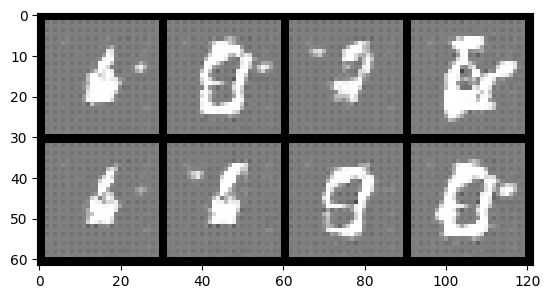

KeyboardInterrupt: 

In [ ]:
EPOCHS = 1500

generated_samples = []

[os.remove(f) for f in glob.glob('checkpoints/generated_samples/*.png')]


from tqdm.auto import trange

for epoch in trange(EPOCHS, desc="Epochs"):
    for real_images, _ in loader:
        ## train disc
        real_images = real_images.to(device)
        batch_size = real_images.shape[0]

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        latent_samples = torch.rand(batch_size, 100).to(device)
        fake_images = generator(latent_samples).detach()
        d_loss_real = criterion(discriminator(real_images), real_labels)
        d_loss_fake = criterion(discriminator(fake_images), fake_labels)
        d_loss_total = d_loss_real + d_loss_fake
        opt_D.zero_grad()
        d_loss_total.backward()
        opt_D.step()
        
        ## train gen
        latent_samples = torch.rand(batch_size, 100).to(device)
        fake_images = generator(latent_samples)
        g_loss = criterion(discriminator(fake_images), real_labels)

        opt_G.zero_grad()
        g_loss.backward()
        opt_G.step()

    torch.save(generator.state_dict(), f"checkpoints/generators/generator_last.pth")
    torch.save(discriminator.state_dict(), f"checkpoints/discriminators/discriminator_last.pth")

    print(f"Epoch {epoch + 1} | D Loss: {d_loss_total.item()} | G Loss: {g_loss.item()}")
    with torch.no_grad():
        samples = generator(torch.rand(8, 100).to(device)).cpu()
        samples = (samples + 1) / 2
        grid = torchvision.utils.make_grid(samples, nrow=4)
        torchvision.utils.save_image(grid, f"checkpoints/generated_samples/generated_samples_epoch_{epoch + 1}.png")
        generated_samples.append(torchvision.transforms.functional.to_pil_image(grid))

        ## show grid in notebook
        clear_output(wait=True)
        plt.imshow(grid.permute(1, 2, 0))
        plt.show()

generated_samples[0].save("checkpoints/progress.gif", save_all=True, append_images=generated_samples[1:], duration=200, loop=0)